# Question 1

## A

### I 

Functions, Simulation, and Estimation (15%)
The exponential decay function
f(t) = Ae−kt,
is often used in finance to describe how the present value of a future payment declines
over time.

Define a function decay(A, k, t) that takes A (float), k (float), and a list t of time
values, and returns a list of computed f(t) values.

In [105]:

def decay(A,k,t):
    res=[]
    for i in t:
        comp=A * np.exp(-k*i)
        res.append(comp)
    return(res)
    



**Comments**

I defined the function decay with A,k,t. Then i made a for loop that returns a list. It loops through the input list t and contruct a f(t) for the different t. Then it append the result to the list res and return this list.

### II
Using the inputs below, call your function and print the resulting values rounded to
two decimals. Explain briefly what happens to the output when k is increased.
A = 100
k = 0.3
t_values = [0 , 1 , 2 , 3 , 4 , 5]

In [114]:
A = 100
k = 0.3
t_values=[0,1,2,3,4,5]

decay(A,k,t_values)

rounded_results = [round(x, 2) for x in decay(A, k, t_values)]
print(rounded_results)


[np.float64(100.0), np.float64(74.08), np.float64(54.88), np.float64(40.66), np.float64(30.12), np.float64(22.31)]


**Comments**

As k increases the resulting values decreases. Hence a negtaive relationship 

### III

Create a dictionary named scenarios containing three different discount rates:
scenarios = {
" Low " : 0.1 ,
" Medium " : 0.3 ,
" High " : 0.6
}

Loop through the dictionary, use your decay() function to compute results for each
case, and store them in a new dictionary results where each key maps to its list of
values. Print the final (last) value for each case on one line.

In [119]:
scenarios = {
"Low" : 0.1 ,
"Medium" : 0.3 ,
"High" : 0.6
}
new_d={}
for state, rate in scenarios.items():
    states = decay(100,rate,t_values)
    new_d[state]=states
    print(f"{state} {states[-1]}")



Low 60.653065971263345
Medium 22.313016014842983
High 4.978706836786395


**Comments** 
I make the new_d as to have a empty dictironary. THen i define the key and the value and state i want to work with the scenarios dictionary. I iterate the values of rate in the decay funtion. Then I fill the new_d with the same state as scenario and allocate the list state to each of them. I then print the state and its last value in ist respectory list.

### IV


Now simulate 100 observed values for the "Medium" case on a dense time grid:
t_sim = [ i * 0.05 for i in range (100)]

Generate noisy observations
yt = Ae−kt + εt, εt ∼N(0,2)

using random.gauss(0, 2) for εt with random.seed(42). 
Store the simulated values in a list y obs. Print the first 10 pairs (t,y) rounded to two decimals, and briefly describe how the noise changes the smooth decay seen earlier.

In [ ]:
import random
t_sim = [i * 0.05 for i in range (100)]

random.seed(42)
error=random.gauss(0,2)

def decay_1(A,k,t,error):
    res=[]
    for i in t:
        comp=A * np.exp(-k*i) + error
        res.append(comp)
    return(res)

y_obs= decay_1(A, 0.3, t_sim,error)
rounded_results = [round(x, 2) for x in y_obs]
print(rounded_results[0:9])


[np.float64(99.71), np.float64(98.22), np.float64(96.76), np.float64(95.31), np.float64(93.89), np.float64(92.49), np.float64(91.1), np.float64(89.74), np.float64(88.4)]
100


**Comments**



### V

Keep the discount rate fixed at k = 0.3 and estimate A from (tsim,yobs) by least
squares. Let wi = exp(−kti). Compute
Implement this formula, print
Arounded to three decimals, and comment briefly on
whether the estimate seems reasonable given the true A= 100.

In [171]:
w_i= [np.exp(-0.3*x) for x in t_sim]

w_i_2=[(x)**2 for x in w_i]

w_i_times_y_i= [x * y for x, y in zip(w_i,y_obs)]

sum_w_i_2= np.sum(w_i_2)

estimate_a= np.sum(w_i_times_y_i) / sum_w_i_2

print(estimate_a)

99.53228946035999


**Comments**

## B

### I

NumPy and Matrix Operations (15%)
You are analyzing three assets with daily returns over four days:
])
import numpy as np
R = np . array ([
[ 0.010 , 0.015 , -0.002 , 0.005] ,
[ 0.005 , -0.004 , 0.012 , 0.009] ,
[ -0.006 , 0.008 , 0.010 , -0.003]
(i) Compute the mean return for each asset and store the result in a 1D array mu. Print
mu rounded to four decimals.

In [183]:
import numpy as np

R = np . array ([
[ 0.010 , 0.015 , -0.002 , 0.005] ,
[ 0.005 , -0.004 , 0.012 , 0.009] ,
[ -0.006 , 0.008 , 0.010 , -0.003]
])

mu = np . array ([
[ np.mean(R[0])] ,
[ np.mean(R[1])] ,
[ np.mean(R[2])]
])

print(np.round(mu,4))



[[0.007 ]
 [0.0055]
 [0.0023]]


**Comments**

I take the mean of each index in R and store it in a new array and round to 4 decimals. Largest return is index 0. 


### II 


Center the data by subtracting each asset’s mean return from its own row 
using broadcasting, producing R centered. Verify that the mean of each row in
R centered is approximately zero.

In [202]:
R_centered= np . array ([
[ R[0] - np.mean(R[0])] ,
[ R[1] - np.mean(R[1])] ,
[ R[2] - np.mean(R[2])]
])

R_verify= np . array ([
[ np.mean(R_centered[0])] ,
[ np.mean(R_centered[1])] ,
[ np.mean(R_centered[2])]
])


print("Means of R_centered returns\n",np.round(R_verify,5))

Means of R_centered returns
 [[-0.]
 [ 0.]
 [-0.]]


**Comments**

The means are subtracted for each return in R_centered. The R_varify confirms that their means are aprrox 0, at least for 5 decimals.. 

### III


Compute the covariance matrix centered, where T is the number of
days. Print Σ rounded to six decimals.

In [232]:

cov = np.cov(R)
print("Covariance matrix:\n", (np.round(cov,6)))


Covariance matrix:
 [[ 5.3e-05 -4.8e-05 -1.3e-05]
 [-4.8e-05  4.8e-05 -6.0e-06]
 [-1.3e-05 -6.0e-06  6.3e-05]]


**Comments**



### IV

In [218]:
x=np.linalg.solve(cov, mu)
print(np.round(x,3))

[[4.318245e+09]
 [4.424937e+09]
 [1.303071e+09]]


### V

In [231]:
# Row-wise standardize
demeaned = x - x.mean(axis=0, keepdims=True)
stdized = demeaned / x.std(axis=0, ddof=0, keepdims=True)
print("Column-wise standardized:\n", stdized)

portfolio_returns = stdized.T @ mu
variance = stdized.T @ cov @ stdized
print("Portfolio variance:", np.round(variance,6))
print("Portfolio returns:", np.round(portfolio_returns,6))

Column-wise standardized:
 [[ 0.66992414]
 [ 0.74364872]
 [-1.41357286]]
Portfolio variance: [[0.000166]]
Portfolio returns: [[0.005599]]


**Comments**

## C

### I
 Fit an Elastic Net model using 5-fold cross-validation and with weight parameters
α= 0.5. Report the test MSE.

In [ ]:
from sklearn.linear_model import ElasticNetCV
pd.set_option('display.float_format', '{:.6f}'.format) #show 6 decimals in coeffs
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


#i, ii, ii 

# Making the pipe
elasticnet_pipe = Pipeline([('scaler', StandardScaler()), ('elastic', ElasticNetCV())]) # Default is l1_ratio= 0.5 and CV= 5 


# fitting and Predicing and computing RMSE
elasticnet_pipe.fit(X_train,y_train)

y_predicted_elastic = elasticnet_pipe.predict(X_test)

# ====================================
# Creating metrics 
# ====================================


MSE_elas = np.mean((y_test - y_predicted_elastic)**2)
print(f"MSE ELAAS: {MSE_elas:.4f}")



MSE ELAAS: 1.5672


**Comments**

So in general compare it ot the test OLS and Lasso.


EXTRA:

The variation in MSE across the cross-validation folds provides an indication of model stability. If the fold errors are relatively consistent, it suggests that the Elastic Net model generalizes well and is not overly sensitive to the specific data split. However, if there is substantial variation in MSE across folds, it indicates that the model’s performance depends heavily on which observations are included in the training set, implying high variance and potential overfitting. In such a case, stronger regularization or adjusting the Elastic Net mixing parameter (α) toward Ridge (which emphasizes stability) could help reduce this sensitivity and improve generalization

### II
Report the selected penalty parameter (λ). How does penalty level compare to that
of Lasso

In [ ]:
best_alpha = elasticnet_pipe.named_steps['elastic'].alpha_

best_l1_ratio = elasticnet_pipe.named_steps['elastic'].l1_ratio_


print(f"Selected penalty (lambda): {best_alpha:.4f}")
print(f"Selected l1_ratio (default settings): {best_l1_ratio:.4f}")



Selected penalty (lambda): 0.0244
Selected l1_ratio (default settings): 0.5000


**Comments**

Larger λ(penalty) → stronger regularization → smaller coefficients → more shrinkage.

Smaller λ(penalty) → weaker regularization → coefficients closer to OLS

Larger λ increases the overall penalty, leading to stronger regularization, smaller coefficients, and greater shrinkage. Conversely, a smaller λ implies weaker regularization, producing coefficients closer to the OLS estimates.
In the Elastic Net, λ controls the total strength of regularization, while the l1_ratio (α) determines how that penalty is divided between the L1 (Lasso) and L2 (Ridge) components. Specifically, α = 1 corresponds to pure Lasso (only L1), and α = 0 corresponds to pure Ridge (only L2).

Lasso: single leash pulling coefficients toward zero.

Elastic Net: two leashes — one pulling directly toward zero (L1), another smoothing the path (L2).
If you tighten both, you need a stronger overall pull (larger λ) to get the same effective shrinkage in each direction

STABLE TUNING
If you refit your Elastic Net multiple times (different train/test splits, or different random seeds), and the selected λ is similar each time, it shows that your model’s tuning is stable

### III
Report the number of selected predictors with non-zero coefficients. Compare this
number to the number of predictors selected by the Lasso.

In [ ]:
# ====================================
# SCALING Lasso coeficient BACK 
# ====================================
 
scaler = elasticnet_pipe.named_steps['scaler']

#get lasso coeff on standardized variables
elastic_coefs_scaled = elasticnet_pipe.named_steps['elastic'].coef_

# Transform back to original scale: divide by scaling factor
elastic_coefs_orig = pd.Series(elastic_coefs_scaled / scaler.scale_)

# ====================================
# Printing the results 
# ====================================
coef_comparison_elastic = pd.DataFrame({
    'Feature': X.columns,
    'ElasticCV': elastic_coefs_orig
})

# ========================================================================
# The features that was selected due to lasso' variable selection # 
# ========================================================================

# Create a boolean mask for coefficients=0
mask_1 = coef_comparison_elastic["ElasticCV"] != 0

print("Variable selected count:", coef_comparison_elastic[mask_1].value_counts().sum() )



Variable selected count: 30


**Comments**

Elasicnet include more variables (30) than Lasso (21).

Elastic Net keeps more features when predictors are correlated because its L2 (Ridge) component encourages grouping: correlated predictors tend to get similar, non-zero coefficients instead of one being dropped (as in Lasso).

If many features are selected but test MSE doesn’t improve, it means the model is too complex (low sparsity).
→ Increasing λ strengthens regularization (shrinks more coefficients).
→ Increasing α (toward 1) puts more weight on L1, promoting sparsity (fewer non-zero coefficients).

## D

### I
Compare the test MSE of the OLS, Lasso, and Elastic Net models. Briefly comment
on which model performs best and why.

In [ ]:
MSE_comparison = {
    'MSE OLS': MSE,
    'MSE Lasso': MSE_lasso ,
    'MSE Elastic': MSE_elas
}

table = pd.DataFrame.from_dict(MSE_comparison, orient='index', columns=['Value'])
print("\n\n", table)¨

# The best performance from the MSE metric was the LASSO, however, they are very close in values the MSE LAsso and MSE elastic 
# The reasoning for the the small difference in the MSE values for each model can be found in the fact that the shrinkage models thrives in an even higher dimensional setting.
# The variable selection feature are espcially usefull when predictors are correlated (feture correlation)
# Elastic net choose more variables than the lasso, the reasoing for this can be found in the fact that the weight was 0.5 (Defatult) for the elastic net, therefore 0.5 on lasso (variable selection) and ridge (non variable selection.)
# When a dataset is more sparse it suggest that there is not many informations i.e. many real coefficient close to 0, Lasso is very good at captureing these, if we are in high dimensional setting where p>n. 
# Limitions for the shinkrage models in this setting is the relative small amount of p. 
# however e



                Value
MSE OLS     1.575009
MSE Lasso   1.566667
MSE Elastic 1.567207


**Comments**

The Ordinary Least Squares (OLS) model produces the highest test MSE, indicating limited generalization ability due to potential overfitting to the training data. Lasso slightly improves performance by introducing shrinkage, which penalizes large coefficients and effectively reduces model variance. This regularization leads to a modest reduction in test MSE, showing that Lasso captures the main predictive signals while discarding noise.
Elastic Net performs comparably to Lasso, suggesting that the combination of L1 and L2 penalties (α = 0.5) provides a balanced trade-off between sparsity and stability. Its L2 component helps manage correlated predictors, while the L1 component enforces shrinkage. The close test MSE values across models imply that both shrinkage methods achieve similar predictive accuracy, but with different coefficient structures and variable retention behavior.

### II
Compare the number of predictors selected by Lasso and Elastic Net. Discuss how
feature group correlations and sparsity influence variable selection.

**Comments**

lasso= 21 predictors Elas= 30

Lasso produces a sparser model by setting many coefficients exactly to zero, leaving only a subset of strong predictors. In contrast, Elastic Net retains more variables because its L2 (Ridge-like) component distributes weights among correlated predictors rather than eliminating all but one. This “grouping effect” is particularly useful when predictors within the same feature category (e.g., valuation or momentum indicators) are highly correlated.
The higher number of selected predictors in the Elastic Net model reflects its ability to preserve correlated signals, improving stability and reducing the risk of arbitrarily excluding relevant features. However, the trade-off is reduced sparsity and slightly less interpretability compared to Lasso.

### III
Discuss the limitations of shrinkage models in this setting and suggest one practical
approach to improve interpretability or predictive performance.

**Comments**


Shrinkage models like Lasso and Elastic Net are designed to reduce variance, but they do so at the cost of introducing bias—since coefficients are pulled toward zero. Even the strongest predictors are partially shrunk, which can distort true effect sizes and make direct interpretation of coefficients less meaningful. Additionally, correlated variables may still appear in the model, especially in Elastic Net, where L2 regularization encourages group retention.
A practical way to mitigate this bias and enhance interpretability is to apply Post-Lasso (or Post-Elastic Net) estimation. This involves refitting a standard OLS model only on the variables selected by the shrinkage model. This second step removes the penalty, restoring unbiased coefficient estimates while maintaining variable selection benefits. Post-Lasso typically improves interpretability, reduces bias, and can further improve predictive accuracy if the initial selection was effective.

# Question 2

## A

### I 
Load the dataset and report its shape (number of rows and columns). Confirm that there are no missing values and that all predictors are numerical.


In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np


print(os.getcwd())

df_2 = pd.read_csv("/Users/jonas/Downloads/MLFin_Shrinkage_Test.csv")

# Printing shape
print("Shape", df_2.shape)

# investigate missing values 
missing_values =df_2.isna().sum().sum()
print("Missing values:", missing_values)

# Counting numerical columns
numerical_col=df_2.select_dtypes(include=[np.number]).shape[1]
print("Numerical columns:",numerical_col)



/Users/jonas/Documents/Visual studio code/Beginner/Workspace/Notes/Exercises ML
Shape (1000, 51)
Missing values: 0
Numerical columns: 51


**Comments**

As there is no missing values and all columnms are numerical we can continue. 
The shape is as stated in the assignement with 1000 obs and 51 features. 


### II
Select one representative variable from each feature group (VAL01, MOM01, QLT01,
SIZ01, RSK01) and the target (y), and report mean and standard deviation for each.
Briefly comment on the results.

In [67]:

summary_stats = df[['y','VAL01','MOM01','QLT01','SIZ01',"RSK01"]].describe().T[['mean','std']]
print(summary_stats)

# All predictors have the same std deviations. Means are fairly close to each other in size. 



           mean      std
y      0.038617 1.524481
VAL01  0.000000 1.000500
MOM01 -0.000000 1.000500
QLT01 -0.000000 1.000500
SIZ01 -0.000000 1.000500
RSK01  0.000000 1.000500


**Comments**

This serve as a sanity check of the data

The means are 0 with a standard deviation of 1, meaning the features are standardized. Here one can detect outliers or if some features have not been standardized. Features must be standardized when running Ridge and Lasso. As they penalize coefficients based on their magnitude. 

For the target variable:
If there is moderate variation of the target there is something too explain. If target std was 1, it would be very differcult to predict. If it was 4 it would be very volatile and diffecult to caputere those large swings.

When one wants to say something economical of the Lasso or rigde coefficients they must be scaled back, one cannot do the one increase of x result in .... when the coefficents still are standardized. 

### III

Construct the feature matrix X and target vector y. Split the data into a training
set (70%) and a test set (30%) using a random seed of 42. Briefly comment on the
purpose of the train-test split.

In [ ]:

X=df_2_clean.drop(["y"],axis=1) 
y=df_2_clean["y"]

# Simple Train/Test Split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,  # sets seed for reproducibility
    shuffle=True      # set to False for time series data
)

# --- Automatically print dataset shapes ---
print("=== Train/Test Split Summary ===")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"\nTraining set size: {len(y_train)} observations ({len(y_train)/len(y)*100:.1f}% of total)")
print(f"Test set size:     {len(y_test)} observations ({len(y_test)/len(y)*100:.1f}% of total)")




**Comments** 

The purpose for splitting data is to have some unseen data to validate the model performance on. 

### IV
Construct the feature matrix X and target vector y. Split the data into a training set
(70%) and a test set (30%) using a random seed of 42. Fit OLS regression model and
report its training and test MSE. Briefly comment on whether the model appears
prone to overfitting, and why shrinkage methods might improve performance.

In [ ]:


# Setting up linear regression 
reg=LinearRegression()

reg.fit(X_train,y_train) #Training set (fit) → learn relationships.

y_predicted = reg.predict(X_test) #Test set (predict) → check if the learned relationships generalize to unseen data.


# Metrics for evaluation 

# FOR TRAINING SET
y_predicted_train = reg.predict(X_train)
MSE_training = np.mean((y_train - y_predicted_train)**2)
print(f"\n OLS MSE training: {MSE_training:.6f}")
# FOR TEST SET 
MSE = np.mean((y_test - y_predicted)**2)
print(f"\n OLS MSE test: {MSE:.6f}")

 



 OLS MSE training: 1.402696

 OLS MSE test: 1.575009


**Comments**

One can combare the models train and test MSE to investigate wheter it is overfitting. 

If the model have similar metrics, it indicate that it performs well on unseen data as well as training data and therefore it indicate stable generalization. 

On the other hand, if the test MSE is larger than the training MSE it indicates that the model is trained to well on the train set (overfitting). Therefore, when presented for the unseen data, it perform worse.

Shrinkage medthods can help reduce the variance if the train /test  gap is large as they add a penalisation term, this reduces the varience but might be on the cost og bias

It prevents the model from fitting noise in the training set. As a result, the model generalizes better (reducing the gap between training and test performance), though this comes at the cost of introducing some bias into the estimates.


## B

### I
Fit a Lasso model (use a 5-fold CV grid) to the training data. Report the selected
penalty parameter λ and the test MSE.

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV


# I 

# Making the pipe
lasso_pipe = Pipeline([('scaler', StandardScaler()), ('lasso', LassoCV(cv=5))])

# fitting and Predicing and computing RMSE
lasso_pipe.fit(X_train,y_train)

y_predicted_lasso = lasso_pipe.predict(X_test)

# ====================================
# Creating metrics 
# ====================================
best_alpha = lasso_pipe.named_steps['lasso'].alpha_

MSE_lasso = np.mean((y_test - y_predicted_lasso)**2)

RMSE_lasso = np.sqrt(MSE)


print(f"MSE Lasso: {MSE_lasso:.5f}")
print(f"Selected alpha/penalty: {best_alpha:.4f}")

# ====================================
# SCALING Lasso coeficient BACK (!!!!NOT NESSCIARY only if assignement says so or we are to compare / interpret the coeffients) 
# ====================================
 
scaler = lasso_pipe.named_steps['scaler']

#get lasso coeff on standardized variables
lasso_coefs_scaled = lasso_pipe.named_steps['lasso'].coef_

# Transform back to original scale: divide by scaling factor
lasso_coefs_orig = pd.Series(lasso_coefs_scaled / scaler.scale_)


# ====================================
# Getting the coeffiecient
# ====================================
coef_comparison_lasso = pd.DataFrame({
    'Feature': X.columns,
    'LassoCV': lasso_coefs_orig
})












MSE Lasso: 1.56667
Selected alpha/penalty: 0.0173


**Comments**

The test MSE slighly decreases from the original MSE. Indicating as stated above an increase in the generalisation(how well it reacts to unseen data)
the selected penalty is 0.0173.

If lambda increases the regularisation would be larger and there would be more shrinkage. 


### II 
Report the number of predictors selected by the Lasso model (i.e., those with non-
zero coefficients).

In [70]:
# ========================================================================
# Counting the variabels selected 
# ========================================================================

# Create a boolean mask for coefficients not equal to 0
mask = coef_comparison_lasso["LassoCV"] != 0



print("Variable selected count:", coef_comparison_lasso[mask].value_counts().sum() )









Variable selected count: 21


**Comments**

The lasso variable selection feature cut away 29 predictors compared to the OLS.

The Lasso model selected 21 predictors with non-zero coefficients, implying a sparse model structure. (The smaller the number of selected predictors the more sparse)
Sparsity means that most coefficients are exactly zero, and only a few predictors remain active.
This reflects Lasso’s variable selection property, which simplifies the model and reduces overfitting by removing weak or redundant predictors.
The degree of sparsity depends on the penalty parameter 
𝜆
λ: higher λ values induce greater sparsity.

### III
Identify which predictors are selected and discuss briefly which feature groups they
belong to.

In [ ]:


# The selected variables 
print("\nThe following variables was selected by Lasso due to variable selection feature:\n", coef_comparison_lasso[mask])





The following variables was selected by Lasso due to variable selection feature:
    Feature   LassoCV
0    VAL01  0.551241
2    VAL03 -0.162474
5    VAL06 -0.057648
6    VAL07 -0.002822
9    VAL10  0.040575
10   MOM01  0.388195
11   MOM02  0.242803
14   MOM05 -0.024064
16   MOM07  0.150697
17   MOM08 -0.058347
19   MOM10  0.021441
20   QLT01  0.012581
21   QLT02  0.383056
26   QLT07 -0.227027
28   QLT09 -0.067870
30   SIZ01 -0.036447
31   SIZ02 -0.003544
38   SIZ09 -0.088687
42   RSK03  0.338181
45   RSK06 -0.042920
48   RSK09 -0.005105


**Comments**

So the groups appearing more often likely contaon the most predictive features, in this case they belong to VAL,MOM, QLT.

The magnitude of the coefficant can also say something, for instance VAL01 has the largest coefficeint and thereby contain more information (only if they are standardized, which they are.)

“This variable was selected by the Lasso model, indicating predictive importance.”

“Among the selected features, momentum and valuation indicators appear most predictive.”

“Variables excluded by Lasso likely carry weak or redundant information.”


## C

### I
 Fit an Elastic Net model using 5-fold cross-validation and with weight parameters
α= 0.5. Report the test MSE.

In [73]:
from sklearn.linear_model import ElasticNetCV
pd.set_option('display.float_format', '{:.6f}'.format) #show 6 decimals in coeffs
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


#i, ii, ii 

# Making the pipe
elasticnet_pipe = Pipeline([('scaler', StandardScaler()), ('elastic', ElasticNetCV())]) # Default is l1_ratio= 0.5 and CV= 5 


# fitting and Predicing and computing RMSE
elasticnet_pipe.fit(X_train,y_train)

y_predicted_elastic = elasticnet_pipe.predict(X_test)

# ====================================
# Creating metrics 
# ====================================


MSE_elas = np.mean((y_test - y_predicted_elastic)**2)
print(f"MSE ELAAS: {MSE_elas:.4f}")



MSE ELAAS: 1.5672


**Comments**

So in general compare it ot the test OLS and Lasso.


EXTRA:

The variation in MSE across the cross-validation folds provides an indication of model stability. If the fold errors are relatively consistent, it suggests that the Elastic Net model generalizes well and is not overly sensitive to the specific data split. However, if there is substantial variation in MSE across folds, it indicates that the model’s performance depends heavily on which observations are included in the training set, implying high variance and potential overfitting. In such a case, stronger regularization or adjusting the Elastic Net mixing parameter (α) toward Ridge (which emphasizes stability) could help reduce this sensitivity and improve generalization

### II
Report the selected penalty parameter (λ). How does penalty level compare to that
of Lasso

In [45]:
best_alpha = elasticnet_pipe.named_steps['elastic'].alpha_

best_l1_ratio = elasticnet_pipe.named_steps['elastic'].l1_ratio_


print(f"Selected penalty (lambda): {best_alpha:.4f}")
print(f"Selected l1_ratio (default settings): {best_l1_ratio:.4f}")



Selected penalty (lambda): 0.0244
Selected l1_ratio (default settings): 0.5000


**Comments**

Larger λ(penalty) → stronger regularization → smaller coefficients → more shrinkage.

Smaller λ(penalty) → weaker regularization → coefficients closer to OLS

Larger λ increases the overall penalty, leading to stronger regularization, smaller coefficients, and greater shrinkage. Conversely, a smaller λ implies weaker regularization, producing coefficients closer to the OLS estimates.
In the Elastic Net, λ controls the total strength of regularization, while the l1_ratio (α) determines how that penalty is divided between the L1 (Lasso) and L2 (Ridge) components. Specifically, α = 1 corresponds to pure Lasso (only L1), and α = 0 corresponds to pure Ridge (only L2).

Lasso: single leash pulling coefficients toward zero.

Elastic Net: two leashes — one pulling directly toward zero (L1), another smoothing the path (L2).
If you tighten both, you need a stronger overall pull (larger λ) to get the same effective shrinkage in each direction

STABLE TUNING
If you refit your Elastic Net multiple times (different train/test splits, or different random seeds), and the selected λ is similar each time, it shows that your model’s tuning is stable

### III
Report the number of selected predictors with non-zero coefficients. Compare this
number to the number of predictors selected by the Lasso.

In [ ]:
# ====================================
# SCALING Lasso coeficient BACK 
# ====================================
 
scaler = elasticnet_pipe.named_steps['scaler']

#get lasso coeff on standardized variables
elastic_coefs_scaled = elasticnet_pipe.named_steps['elastic'].coef_

# Transform back to original scale: divide by scaling factor
elastic_coefs_orig = pd.Series(elastic_coefs_scaled / scaler.scale_)

# ====================================
# Printing the results 
# ====================================
coef_comparison_elastic = pd.DataFrame({
    'Feature': X.columns,
    'ElasticCV': elastic_coefs_orig
})

# ========================================================================
# The features that was selected due to lasso' variable selection # 
# ========================================================================

# Create a boolean mask for coefficients=0
mask_1 = coef_comparison_elastic["ElasticCV"] != 0

print("Variable selected count:", coef_comparison_elastic[mask_1].value_counts().sum() )



Variable selected count: 30


**Comments**

Elasicnet include more variables (30) than Lasso (21).

Elastic Net keeps more features when predictors are correlated because its L2 (Ridge) component encourages grouping: correlated predictors tend to get similar, non-zero coefficients instead of one being dropped (as in Lasso).

If many features are selected but test MSE doesn’t improve, it means the model is too complex (low sparsity).
→ Increasing λ strengthens regularization (shrinks more coefficients).
→ Increasing α (toward 1) puts more weight on L1, promoting sparsity (fewer non-zero coefficients).

## D

### I
Compare the test MSE of the OLS, Lasso, and Elastic Net models. Briefly comment
on which model performs best and why.

In [ ]:
MSE_comparison = {
    'MSE OLS': MSE,
    'MSE Lasso': MSE_lasso ,
    'MSE Elastic': MSE_elas
}

table = pd.DataFrame.from_dict(MSE_comparison, orient='index', columns=['Value'])
print("\n\n", table)¨

# The best performance from the MSE metric was the LASSO, however, they are very close in values the MSE LAsso and MSE elastic 
# The reasoning for the the small difference in the MSE values for each model can be found in the fact that the shrinkage models thrives in an even higher dimensional setting.
# The variable selection feature are espcially usefull when predictors are correlated (feture correlation)
# Elastic net choose more variables than the lasso, the reasoing for this can be found in the fact that the weight was 0.5 (Defatult) for the elastic net, therefore 0.5 on lasso (variable selection) and ridge (non variable selection.)
# When a dataset is more sparse it suggest that there is not many informations i.e. many real coefficient close to 0, Lasso is very good at captureing these, if we are in high dimensional setting where p>n. 
# Limitions for the shinkrage models in this setting is the relative small amount of p. 
# however e



                Value
MSE OLS     1.575009
MSE Lasso   1.566667
MSE Elastic 1.567207


**Comments**

The Ordinary Least Squares (OLS) model produces the highest test MSE, indicating limited generalization ability due to potential overfitting to the training data. Lasso slightly improves performance by introducing shrinkage, which penalizes large coefficients and effectively reduces model variance. This regularization leads to a modest reduction in test MSE, showing that Lasso captures the main predictive signals while discarding noise.
Elastic Net performs comparably to Lasso, suggesting that the combination of L1 and L2 penalties (α = 0.5) provides a balanced trade-off between sparsity and stability. Its L2 component helps manage correlated predictors, while the L1 component enforces shrinkage. The close test MSE values across models imply that both shrinkage methods achieve similar predictive accuracy, but with different coefficient structures and variable retention behavior.

### II
Compare the number of predictors selected by Lasso and Elastic Net. Discuss how
feature group correlations and sparsity influence variable selection.

**Comments**

lasso= 21 predictors Elas= 30

Lasso produces a sparser model by setting many coefficients exactly to zero, leaving only a subset of strong predictors. In contrast, Elastic Net retains more variables because its L2 (Ridge-like) component distributes weights among correlated predictors rather than eliminating all but one. This “grouping effect” is particularly useful when predictors within the same feature category (e.g., valuation or momentum indicators) are highly correlated.
The higher number of selected predictors in the Elastic Net model reflects its ability to preserve correlated signals, improving stability and reducing the risk of arbitrarily excluding relevant features. However, the trade-off is reduced sparsity and slightly less interpretability compared to Lasso.

### III
Discuss the limitations of shrinkage models in this setting and suggest one practical
approach to improve interpretability or predictive performance.

**Comments**


Shrinkage models like Lasso and Elastic Net are designed to reduce variance, but they do so at the cost of introducing bias—since coefficients are pulled toward zero. Even the strongest predictors are partially shrunk, which can distort true effect sizes and make direct interpretation of coefficients less meaningful. Additionally, correlated variables may still appear in the model, especially in Elastic Net, where L2 regularization encourages group retention.
A practical way to mitigate this bias and enhance interpretability is to apply Post-Lasso (or Post-Elastic Net) estimation. This involves refitting a standard OLS model only on the variables selected by the shrinkage model. This second step removes the penalty, restoring unbiased coefficient estimates while maintaining variable selection benefits. Post-Lasso typically improves interpretability, reduces bias, and can further improve predictive accuracy if the initial selection was effective.

# Question 3

## A

### I

What types of variables does it contain, and what do you notice about their
distributions or levels of variation? Discuss any patterns or group differences
that might be relevant for prediction.


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   style            947 non-null    object 
 1   listing          943 non-null    object 
 2   carry_yield      955 non-null    float64
 3   vol_of_vol       961 non-null    float64
 4   short_interest   956 non-null    float64
 5   option_skew      956 non-null    float64
 6   macro_beta       939 non-null    float64
 7   excess_7d_alpha  1000 non-null   float64
dtypes: float64(6), object(2)
memory usage: 62.6+ KB
None
     style listing  carry_yield  vol_of_vol  short_interest  option_skew  \
0      NaN    NYSE     0.023091    0.095526        0.026940     0.024199   
1    Value    NYSE          NaN    0.067890        0.008188    -0.186564   
2   Growth  NASDAQ     0.036231    0.065889        0.047342     0.942482   
3  Quality    NYSE     0.021718    0.031883        0.079843     0.

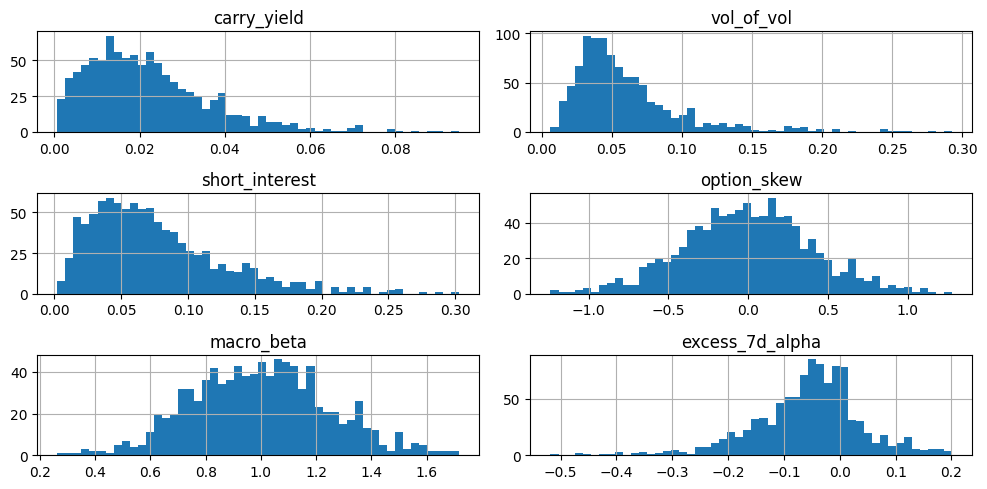

In [171]:
import matplotlib as plt
import matplotlib.pyplot as plt
df_3 = pd.read_csv("/Users/jonas/Downloads/MLFin_Trees_test.csv")

# variable types 
print("\nInfo:")
print(df_3.info())

# first rows 
print(df_3.head(10))
columns=df_3.columns

# Value count in categorial columns
cat_cols=df_3[["style","listing"]]
for c in cat_cols:
    count=df_3[c].value_counts(dropna=False)
    print(f"\n{count}")

df_3[columns].hist(figsize=(10,5), bins=50) # bins is the thickness of the bars, .hist creates a histogram for each columnn in the dataframe
plt.tight_layout()

**Comments**

It contains floats and two object variables (style and listing)
The differenet distribtuions are grapfhed here carry, vol of vol, shot_interest are right skewed, option_skew and macro beta look fairly normal whereas the target is left skewed all the above mentioned is only by graphical inspection. 

The categorical balance is uneven. In style, “Growth” firms (332) dominate while “Dividend” firms (137) are least represented. In listing, NYSE (436) and NASDAQ (426) together make up most observations, whereas LSE (81) is underrepresented. Such imbalances could bias model estimates if not accounted for.

As the ranges in the variables in relation to each other differs, standardization is required for models that are scale sensitive i.e. (LAsso, ridge, elasticenet and KNN.)


The limited variation in excess_7d_alpha implies that the prediction target may be difficult to explain strongly with linear models alone. Non-linear or interaction effects may contribute more predictive power, making tree-based methods useful extensions.

for preditcion the categorial variables must be made into dummies. 


### II

Check for missing values and outliers in the continuous variables. Describe how
you detect and handle them, and briefly justify your approach for tree-based
models using statistics, visuals, or code.


Missing values per column:
style              53
listing            57
carry_yield        45
vol_of_vol         39
short_interest     44
option_skew        44
macro_beta         61
excess_7d_alpha     0
dtype: int64

Total missing values: 343
carry_yield: 26 outliers by IQR rule
vol_of_vol: 58 outliers by IQR rule
short_interest: 31 outliers by IQR rule
option_skew: 10 outliers by IQR rule
macro_beta: 6 outliers by IQR rule
excess_7d_alpha: 47 outliers by IQR rule


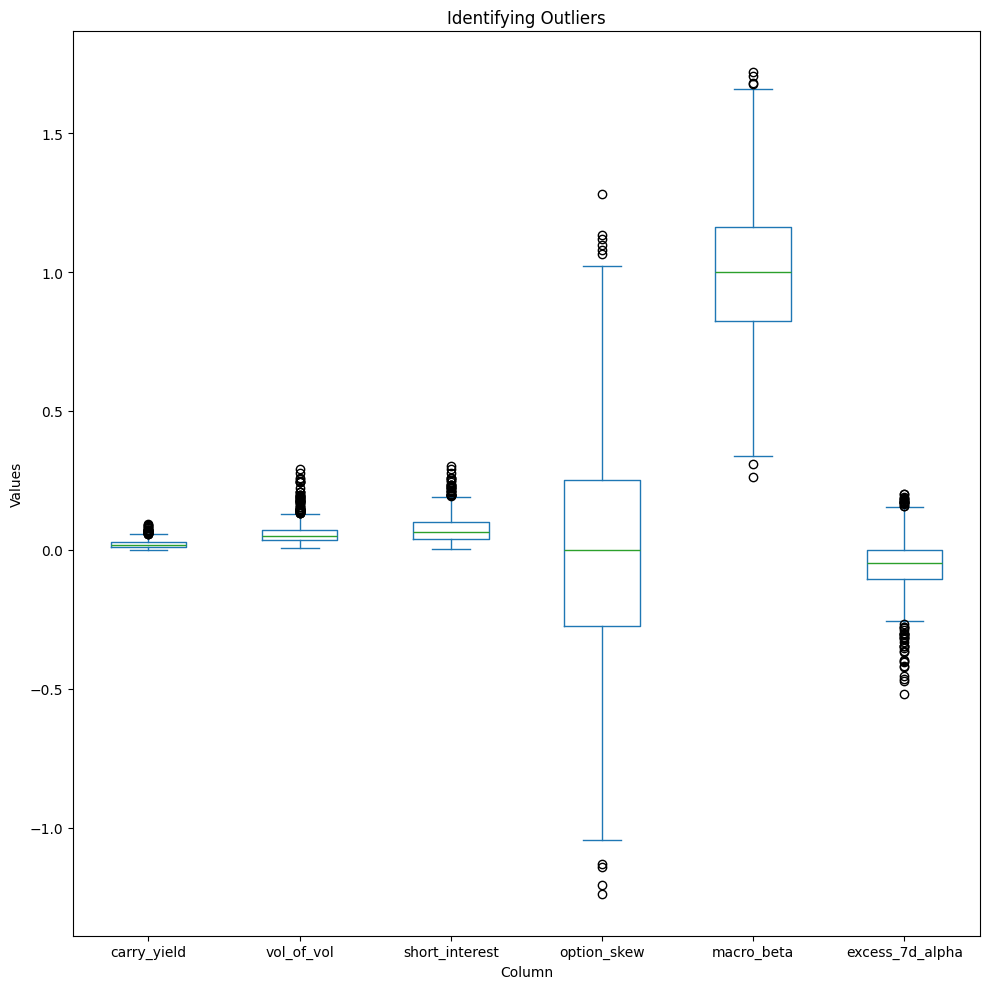

In [121]:
# missing values 
missing_values = df_3.isna().sum()
print("\nMissing values per column:")
print(missing_values)
print("\nTotal missing values:", missing_values.sum())

# Outliers 
# IQR

for col in df_3[columns_target]:
    Q_1= df_3[col].quantile(0.25) # will return a single number. the quantile takes all the observations in col and take the first quantile
    Q_3= df_3[col].quantile(0.75) # same for this 
    IQR= Q_3 - Q_1 # single number 
    lower_bound= Q_1 - 1.5*IQR
    Upper_bound= Q_3 + 1.5*IQR
    outliers = ((df_3[col]< lower_bound) | (df_3[col]> Upper_bound)).sum() # Here, box_plt[col] contains all the observations inside X1 which is compared to the bounderies.
    #  | means or, so only one of the expressions have to be true for the sum to count it as true. In this way it capture every obs < lower_bound and > upper_ bound
    # In this way, if the value in col is below lower_bound = true sum counts 1
    # If it is below lower_bound but above the upper bound it is true and the sum counts it
    # If it is inbetween both are statements are false and the .sum() does not count it
    # The .sum then count the true values, hence either below lower or above upper limit i.e. outliers 
    print(f"{col}: {outliers} outliers by IQR rule")







#Chosing the numerical columns
columns_target = df_3.select_dtypes(include=[np.number]).columns.tolist()
boxplot= df_3[columns_target]

#creating the boxplot 
fig, ax = plt.subplots(figsize=(10,10))
boxplot.plot(kind='box',ax=ax)
ax.set_title("Identifying Outliers")
ax.set_xlabel("Column")
ax.set_ylabel("Values")
plt.tight_layout()
plt.show()

**Comments**

the boxplot does not show clear evidence of outliers (the black dots). 
one can detect outliers by visual inspecting the boxblot plovided, however one must put the outliers into  a contexts as some out the outliers may reflect genuine economic variation rather than data errors but suggest the need for standardization or robust estimation to limit their influence.


One can use the IQR rule which set a threshold as a lower and upper bound for being a outlier, isolation forrest can also be applied. Missing values can either by MCAR, MAR or MNAR. For us to handle them they must be MCAR, they are identified by the MCAR test. 
They can be handled in multiple ways:

missing values: we can impute by mean, median or forward/backward full (time series) or model compute them either by regression or KNN, we can also utilize MICE imputations
Outliers Can be handled by Winsorizing & Robust Scaling. 


Outliers can be detected using the IQR rule (values beyond 1.5×IQR) or model-based methods such as Isolation Forest. They can be handled through Winsorizing (capping extremes) or Robust Scaling (using medians and IQRs).

Missing values can occur as MCAR, MAR, or MNAR. Only when they are MCAR—verified through an MCAR test—can they be handled without bias. Common imputation methods include mean, median, forward/backward fill, or model-based approaches such as regression, KNN, or MICE imputation to preserve data integrity.

**Tree-based methods don’t require scaling or transformations.**

### III

 Prepare the features for modeling: encode categorical variables, transform con-
tinuous ones if needed, and build X and y. Briefly discuss how preprocessing
choices affect learning and how to ensure consistency between training and fu-
ture data.

In [173]:

df_3_filled = df_3.copy()
for col in df_3[columns_target]:
    df_3_filled[col] = df_3[col].fillna(df_3[col].median())

for col in df_3[["listing","style"]]:
    df_3_filled[col] = df_3[col].fillna(df_3[col].mode()[0])

df_3_one_hot_encoding = pd.get_dummies(
    df_3_filled,
    columns=df_3_filled.select_dtypes(include=["object","category"]).columns,
    prefix="one_hot_encoded",
    drop_first=True)
print(df_3_one_hot_encoding.head(10))

# Summary statistics
summary_stats = df_3_filled.describe().T[['mean','std']]
print(summary_stats)

X=df_3_one_hot_encoding.drop(["excess_7d_alpha"],axis=1)
y= df_3_one_hot_encoding["excess_7d_alpha"]

   carry_yield  vol_of_vol  short_interest  option_skew  macro_beta  \
0     0.023091    0.095526        0.026940     0.024199    1.492288   
1     0.019317    0.067890        0.008188    -0.186564    0.949392   
2     0.036231    0.065889        0.047342     0.942482    1.153069   
3     0.021718    0.031883        0.079843     0.870190    1.000658   
4     0.003808    0.048863        0.054146    -0.482825    0.937601   
5     0.003815    0.050726        0.144548     0.212233    1.264141   
6     0.015331    0.189047        0.125111    -0.192795    0.957814   
7     0.025535    0.023024        0.164858    -0.608835    1.000658   
8     0.002168    0.030836        0.069202     0.587664    0.927167   
9     0.000989    0.020984        0.152377    -0.497334    0.773369   

   excess_7d_alpha  one_hot_encoded_Growth  one_hot_encoded_Quality  \
0        -0.027419                    True                    False   
1        -0.060057                   False                    False   
2    

**Comments**

**FOR TREE MODELS**

Tree-based models, such as Decision Trees, Random Forest, and Gradient Boosting, are not sensitive to feature scaling because they split data based on thresholds rather than distance or magnitude.
Therefore, standardization or normalization does not affect their performance.

Similarly, one-hot encoding is not strictly required, as trees can handle categorical splits directly (or via label encoding).
However, ensuring consistent encoding and category handling between training and future data remains important—mismatched category levels can lead to missing or misclassified splits.

In short, preprocessing mainly affects data consistency, not model performance, for tree algorithms

**FOR SCALE SENSITIVE MODELS**

Categorical variables are encoded using one-hot encoding (with drop_first=True to avoid perfect collinearity), while continuous variables are standardized or scaled to ensure all features contribute comparably to the model, especially in regularized or distance-based algorithms (e.g., Lasso, Ridge, Elastic Net, KNN).

Preprocessing choices affect model learning by influencing coefficient magnitudes, penalty strength, and convergence.
Inconsistent preprocessing can cause data leakage or biased estimates if transformations are fitted on the entire dataset rather than the training set.

To ensure consistency between training and future (test) data, transformations should be implemented through a pipeline or fitted only on the training data, then applied to new data using the same parameters (e.g., same means and standard deviations for scaling).
This guarantees reproducibility and prevents future data from influencing model fitting.

### IV

**Comments**

### V

**Comments**

## B

### I

Before fitting a complex model, you will define a baseline and validation scheme.
(i) Split the dataset into training and test sets. Comment on the importance of
using random seeds and reproducibility in such splits

In [174]:
# Simple Train/Test Split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,  # sets seed for reproducibility
    shuffle=True      # set to False for time series data
)

# --- Automatically print dataset shapes ---
print("=== Train/Test Split Summary ===")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"\nTraining set size: {len(y_train)} observations ({len(y_train)/len(y)*100:.1f}% of total)")
print(f"Test set size:     {len(y_test)} observations ({len(y_test)/len(y)*100:.1f}% of total)")

=== Train/Test Split Summary ===
X_train shape: (750, 10)
X_test shape:  (250, 10)
y_train shape: (750,)
y_test shape:  (250,)

Training set size: 750 observations (75.0% of total)
Test set size:     250 observations (25.0% of total)


**Comments**

I split the data to have 850 obs for traning and 250 for testing.Which ensures enough data for training and testing. 

Random seed make it possible to compare different models, as the train and test set will be fairly the same. 

Random seed ensures reproducible splits, allowing fair model comparison. Without it, model results could differ due to random variation in the data split.

### II

Choose a baseline model of your own design and print its Mean Squared Error
(MSE). Argue why your baseline is a reasonable benchmark for this task.

In [185]:
# Baseline 
base_predict= np.repeat(y_train.mean(),len(y_test))

base_mse=mean_squared_error(y_test,base_predict)

print(round(base_mse,6))

0.009572


**Comments**

As linear regression is one of the simplist models this is the baseline. 

### III

Explain why cross-validation can provide a more reliable estimate of model per-
formance than a single hold-out split.

**Comments**

Cross-validation does split the data into multiple folds (subsets).

Each fold acts as a validation set once and as part of the training set the other times.

This repeated resampling provides multiple estimates of performance, which are averaged.

This makes the final estimate less sensitive to how the data happened to be split once (like in a single hold-out split)

## IV
In what situations might cross-validation estimates still be misleading, and how
could you detect this?

**Comments**

cv for time series must be handled properly as one cannont just resample randomly it must be ordered one rolling or expaning window. In these two methods one must also consider the weight on early on newer data.moreover the computational cost for CV can be very large especially for LOOCV

## V

**Comments**

## C

### I

Train and evaluate a BaggingRegressor to predict excess 7d alpha.
(i) Fit an initial Bagging model on the training data and report training and val-
idation MSE. Discuss briefly whether the model shows signs of underfitting or
overfitting.

In [176]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import r2_score, mean_squared_error



bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=100,      
    bootstrap=True,
    random_state=42
)
bag.fit(X_train, y_train)
y_train_bag=bag.predict(X_train)
y_test_bag=bag.predict(X_test)

print("Train MSE:", round(mean_squared_error(y_train,y_train_bag),6))
print("Test MSE", round(mean_squared_error(y_test,y_test_bag),6))




Train MSE: 0.000128
Test MSE 0.001249


**Comments**

As there is a large gap between the MSE it indicate it is overfitting as it predict very well on the training but worse on new unseen data (the validatio / test set.)

### II

Tune at least three key hyperparameters using a suitable validation scheme
and record how performance changes. Summarize how you selected the final
configuration.

In [177]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor


n_trees=[100,200,300]
r2_test_plt=[]
r2_oob_plt=[]
mse_test_result=[]
mse_oob_result=[]


for i in n_trees:
    bag = BaggingRegressor(n_estimators=i,oob_score=True,bootstrap=True, random_state=42)
    bag.fit(X_train, y_train) 
    oob_pred = bag.oob_prediction_ #an array of predicted values for each training observation — based only on the trees that did not see that observation (the OOB trees).
    r2_test=bag.score(X_test, y_test) # Standard R² from test data
    r2_oob=bag.oob_score_ # R² based on OOB predictions
    test_mse= mean_squared_error(y_test,bag.predict(X_test))
    oob_mse= mean_squared_error(y_train,oob_pred) # must be y_train 
    mse_test_result.append(test_mse)
    mse_oob_result.append(oob_mse)
    r2_oob_plt.append(r2_oob)
    r2_test_plt.append(r2_test)
    print(f"n_estimators= {i}: Test R_2: {r2_test:.2f} OOB R_2: {r2_oob:.2f}")
    print(f"n_estimators= {i}: Test MSE: {test_mse:.6f} OOB MSE: {oob_mse:.6f}")







n_estimators= 100: Test R_2: 0.87 OOB R_2: 0.91
n_estimators= 100: Test MSE: 0.001249 OOB MSE: 0.000891
n_estimators= 200: Test R_2: 0.87 OOB R_2: 0.91
n_estimators= 200: Test MSE: 0.001248 OOB MSE: 0.000866
n_estimators= 300: Test R_2: 0.87 OOB R_2: 0.91
n_estimators= 300: Test MSE: 0.001253 OOB MSE: 0.000863


**COMMENTS**

#### Interpretation of OOB and Test Results in Bagging

When evaluating a Bagging Regressor, the relationship between the **Out-of-Bag (OOB)** performance and the **Test set** performance provides important insight into how well the model generalizes.  
Below are five common scenarios and their interpretations.

---

##### 1. OOB and Test results are close (ideal scenario)
**Example:**  
OOB R² = 0.92, Test R² = 0.85  
OOB MSE = 0.00075, Test MSE = 0.0014  

**Interpretation:**  
- Indicates good generalization — the model performs similarly on unseen data.  
- The small gap between OOB and Test performance reflects mild, expected overfitting.  
- Performance stabilizes as the number of trees increases → the model has converged.  
✅ **This is the ideal and desired outcome.**

---

##### 2. OOB much higher than Test
**Example:**  
OOB R² = 0.95, Test R² = 0.70  
OOB MSE = 0.0004, Test MSE = 0.003  

**Interpretation:**  
- Strong indication of **overfitting**.  
- The model fits resampled training data too well but fails on unseen data.  
- **Possible causes:** trees too deep, too few samples per leaf, or a small dataset.  
- **Fix:** reduce model complexity (e.g., limit `max_depth`, increase `min_samples_leaf`).  

---

##### 3. Both OOB and Test scores low and similar
**Example:**  
OOB R² = 0.40, Test R² = 0.42  

**Interpretation:**  
- The model is **underfitting** — it fails to capture underlying patterns.  
- Similar performance on OOB and Test confirms that it’s not overfitting.  
- **Possible causes:** trees too shallow, too few estimators, or weak features.  
- **Fix:** allow deeper trees, increase `n_estimators`, or use a more expressive model.  

---

##### 4. OOB and Test improve as the number of trees increases
**Example:**  
50 trees → OOB R² = 0.70, Test R² = 0.68  
200 trees → OOB R² = 0.82, Test R² = 0.80  

**Interpretation:**  
- Normal and expected pattern during training.  
- Bagging reduces variance through averaging; more trees improve stability.  
- Continue increasing `n_estimators` until performance plateaus.  
 **Indicates that the ensemble is still learning effectively.**

---

##### 5. OOB decreases as number of trees increases
**Example:**  
50 trees → OOB R² = 0.90  
300 trees → OOB R² = 0.82  

**Interpretation:**  
- Unusual but possible behavior.  
- Often caused by randomness, unstable sampling, or noisy data.  
- Overfitting is unlikely (Bagging rarely overfits by adding trees).  
- **Fix:** ensure consistent `random_state`, check data quality, or average across multiple runs.  

---

#####  Summary Table

| Pattern | Interpretation | Likely Cause | Recommended Action |
|----------|----------------|--------------|--------------------|
| OOB ≈ Test (both high) | Good generalization | Balanced bias-variance | ✅ Stable model |
| OOB ≫ Test | Overfitting | Model too complex | Simplify model |
| OOB ≈ Test (both low) | Underfitting | Model too simple | Increase depth / estimators |
| Both improve with n_estimators | Normal convergence | Variance reduction | Keep adding trees until plateau |
| OOB decreases with n_estimators | Instability | Noise or randomness | Check data / random_state |

---


In [186]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
# --- Bagging ensemble of trees ---
bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# --- Expanded hyperparameter grid ---
param_grid = {
    "n_estimators": [100, 300, 600],       # Number of trees in ensemble
    "estimator__max_depth": [4, 8, 12],          # Depth of each base tree
    "estimator__min_samples_leaf": [1, 3, 5],    # Controls leaf node size
}

# --- Grid Search ---
gcv_bag = GridSearchCV(
    estimator=bag,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    refit=True
)

# --- Fit and evaluate ---
gcv_bag.fit(X_train, y_train)
print("Best Bagging params:", gcv_bag.best_params_)
print("Best CV MSE:", round(-gcv_bag.best_score_, 6))




Best Bagging params: {'estimator__max_depth': 12, 'estimator__min_samples_leaf': 1, 'n_estimators': 300}
Best CV MSE: 0.000871


**Comments**

so the tunes parameters best values are stated above.  

The best-performing Bagging model (among all tested parameter settings) had an average validation MSE of 0.000871 across the k folds of cross-validation

### III

Retrain the tuned model on the full training data and evaluate it on the test
set. Report and interpret the results.

In [188]:
# --- Test evaluation ---
bag_best = gcv_bag.best_estimator_
y_pred_bag = bag_best.predict(X_test)
mse_bag_tuned= mean_squared_error(y_test, y_pred_bag)
print("Test MSE (tuned_Bagging):", round(mse_bag_tuned,6) )



Test MSE (tuned_Bagging): 0.001254


**Comments**

this is the tuned bagging models MSE, so this showcase the best out of sample performance (with the tuning we did)

### IV

Bagging averages predictions from multiple models built on resampled data.
How does this affect variance and interpretability compared to using a single
model?

**Comments**

Bagging: variance and interpretability
Averaging many resampled trees lowers prediction variance (more stable, less sensitive to a single split).
Interpretability is reduced because no single tree explains the prediction.
 

### V

**Comments**

## D

### I
Compare your model’s performance to the baseline. Is the improvement mean-
ingful from both a statistical and practical perspective?

In [191]:
print("tuned_bagging MSE:", round(mse_bag_tuned,6))
print("Base case MSE:", round(base_mse,6))
improvement_pct = (base_mse - mse_bag_tuned) / base_mse * 100
print(f"Improvement vs baseline: {improvement_pct:.2f}%")

tuned_bagging MSE: 0.001254
Base case MSE: 0.009572
Improvement vs baseline: 86.89%


**Comments**

There is a clear improvment in terms of the MSE 87% improvement. 

If using Bagging increases computational cost or complexity but reduces MSE only slightly (say 2–3%), it may not be worth it.

But here, an 87% reduction in MSE is large — likely both statistically and economically meaningful.
→ In a financial or predictive setting, that could translate to better forecasts, less risk, and improved decision-making.

### II

Plot predicted vs. actual values for the test set. Describe whether errors seem
evenly distributed or concentrated in certain ranges of the target variable.

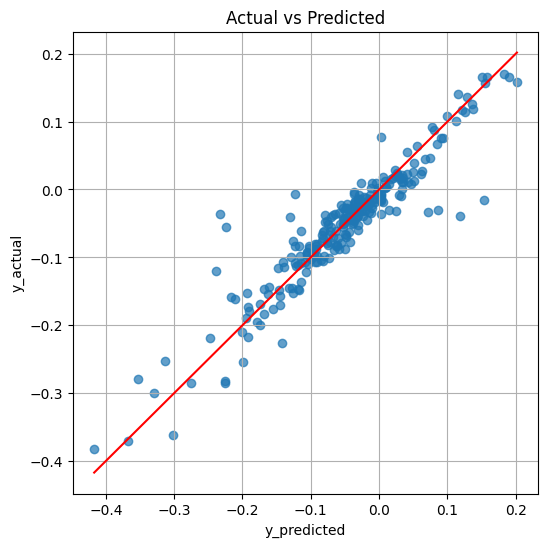

In [194]:
plt.figure(figsize=(6, 6))
plt.scatter( y_test,y_pred_bag, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r') #r is the color red adding -- make it dashed. min, max makes the 45 degree line. 
plt.xlabel('y_predicted')
plt.ylabel('y_actual')
plt.title('Actual vs Predicted')
plt.grid(True) # acivates grid
plt.show()

**Comments**

| Case | Description | Interpretation & Guidance |
|------|--------------|----------------------------|
| ✅ **Ideal (y ≈ x)** | Points lie evenly and tightly along the 45° diagonal line (y = x). | This indicates that the model’s predictions closely match the actual values with minimal systematic error. The spread around the line is narrow and symmetric, showing that residuals are small and unbiased. This is the desired case, suggesting the model generalizes well to unseen data. |
| ⚠️ **Systematic bias** | Points fall consistently above or below the diagonal line. | This occurs when the model consistently overpredicts (points below the line) or underpredicts (points above the line). It suggests the model’s intercept or coefficients are biased, possibly due to omitted variables or insufficient complexity. You may need to recalibrate the model, include more relevant predictors, or allow more flexibility (e.g., deeper trees, nonlinear terms). |
| ⚠️ **Nonlinearity** | The scatter pattern shows curvature (e.g., U-shaped or inverted U). | Indicates that the model is too rigid to capture nonlinear relationships in the data. Linear models often show this pattern when the underlying relationship is curved. The solution is to use models that can represent nonlinearities (e.g., tree-based methods, polynomial regression, or kernel methods). |
| ⚠️ **Heteroskedasticity** | The variance of residuals increases (or decreases) with the magnitude of x or y. | In this case, prediction errors are not evenly distributed — they grow larger for certain ranges of the target variable. This means the model’s uncertainty depends on the target value. Consider transforming the target variable (e.g., log-scale) or applying models that handle varying error variance (e.g., quantile regression). |
| ⚠️ **Regime clustering** | Two or more distinct clouds or lines of points appear instead of a single trend. | Suggests the presence of different data-generating regimes or subgroups (e.g., different sectors, time periods, or market states). The model fails to capture these interactions. You can add categorical features or fit separate models for each regime to address this issue. |

---

**Interpretation Summary:**  
A Predicted vs. Actual plot is an essential diagnostic tool for regression analysis.  
- When points align closely along the diagonal, it confirms that the model predictions are accurate and well-calibrated.  
- Deviations from this line reveal systematic model issues such as bias, unmodeled nonlinearities, or variance irregularities.  
Analyzing these visual patterns helps determine whether improvements should come from model tuning, adding new variables, or changing model families.
. 

### III

Discuss the limitations of ensemble models when used for financial prediction,
and suggest a practical way to address them.

**Comments**

one limitation is the loss of interpretability. When using ensemble models we can no longer do inference as good as with other models. However a unique feature is with the most important feature mechanism which highligst the features that have the largest influence on the model. One thereby have a good prediction model which still contatins some degree of interpretability. Another limitation is the computational cost for the ensemble models, can get quickly out of hand. 

so one most decide whether accurcy or insight is most important. 

**ADDITIONAL COMMETNS ON LIMITATIONS**

**Ensembles** are machine learning models that combine the predictions of multiple base learners (such as decision trees) to produce a more accurate and robust final output. Common examples include **Bagging (Bootstrap Aggregating)** like Random Forests, **Boosting** such as XGBoost or Gradient Boosting, and **Stacking**, where multiple models’ outputs are combined using another meta-model. The fundamental idea is that a collection of weak or moderately strong models, when aggregated, can outperform a single model by reducing variance and improving predictive stability.

---

**Limitations and Practical Mitigation**

Although ensembles often achieve high predictive accuracy, they come with several important limitations, particularly in financial modeling.

**1. Overfitting Subtle Noise**  
Ensembles can capture small, random fluctuations in the data, mistaking noise for true patterns. This problem is especially pronounced in finance, where data are noisy and relationships shift over time. Overfitting leads to poor generalization on unseen data.  
*Mitigation:* Use a true **out-of-time test split** (training on earlier periods, testing on later ones) to simulate real forecasting. Limit model complexity (e.g., control tree depth or minimum leaf size). Use **cross-validation** to monitor generalization performance and detect overfitting early.

**2. Lack of Interpretability**  
Because ensembles average or boost many decision trees, it is difficult to understand how individual variables influence predictions. This is problematic in finance, where transparency and explainability are crucial for compliance and managerial trust.  
*Mitigation:* Apply interpretability tools such as **feature importance rankings**, **SHAP values**, or **partial dependence plots (PDPs)**. Re-fit the model on multiple bootstrap samples to test **stability of feature importances** and identify consistent predictors.

**3. Non-stationarity of Financial Data**  
Financial relationships are rarely constant over time—market structures, macroeconomic regimes, and investor behaviors shift, causing models trained on historical data to become outdated.  
*Mitigation:* Use **rolling or walk-forward validation**, where the model is repeatedly trained on recent data and tested on the next time segment. Continuously monitor performance over time and re-train when significant drift or degradation is observed.

**4. Data Leakage and Stability Issues**  
Data leakage occurs when predictors contain future information unavailable at prediction time, leading to overly optimistic results. Ensemble methods can also produce unstable feature importance rankings due to randomness in sampling or model initialization.  
*Mitigation:* Carefully check that all predictor variables are lagged appropriately relative to the target. Perform **bootstrap-based stability tests** by retraining models on resampled datasets to examine variation in R² or MSE. Analyze **performance dispersion** to ensure the model behaves consistently across samples.

---

**Summary Table**

| Limitation | Why It Matters in Finance | Mitigation Strategy |
|-------------|----------------------------|---------------------|
| Overfitting subtle noise | Markets contain random fluctuations mistaken for real signals | Out-of-time test splits, limit complexity, cross-validation |
| Low interpretability | Financial models must be explainable for trust and compliance | Use SHAP values, feature importance, PDPs |
| Non-stationarity | Market conditions change, breaking historical patterns | Rolling/walk-forward validation, periodic retraining |
| Data leakage & instability | Inflated performance and unreliable results | Time-based splits, bootstrap stability checks |

---

**Summary:**  
Ensemble models such as Bagging, Random Forests, and Boosting provide powerful predictive accuracy by reducing variance and combining multiple learners. However, in financial data, they must be applied with care. Noise, non-stationarity, and the need for interpretability make it essential to validate models out-of-time, test for stability, and ensure transparency. Doing so allows ensembles to be not only accurate but also reliable and useful for real-world financial decision-making.


**Are Bagging, Gradient Boosting, XGBoost, and Random Forest Ensemble Models?**

Yes — all four are ensemble models. Ensemble methods combine multiple base learners (usually decision trees) to create a stronger and more reliable model. While they share this common principle, they differ in how they build and combine these trees.

| Model | Type of Ensemble | Key Mechanism | Description |
|--------|------------------|----------------|--------------|
| **Bagging (Bootstrap Aggregating)** | Parallel ensemble | Averages predictions from many independent trees trained on random bootstrap samples | Reduces variance and improves model stability. Each tree sees a slightly different dataset. |
| **Random Forest** | Bagging variant | Adds random feature selection at each split | Further decorrelates trees and improves generalization by introducing additional randomness. |
| **Gradient Boosting** | Sequential ensemble | Builds trees one after another, each correcting errors made by the previous model | Reduces bias and models complex relationships, but can overfit if not tuned properly. |
| **XGBoost (Extreme Gradient Boosting)** | Optimized boosting | Combines gradient boosting with regularization and computational optimization | Faster and more accurate than classical boosting; handles overfitting with L1/L2 penalties and shrinkage. |

In summary:
- **Bagging and Random Forest** primarily reduce variance.
- **Boosting and XGBoost** primarily reduce bias.
All are ensemble models because they aggregate multiple weak learners (trees) into a single strong predictive model.

---

**Limitations of CART (Classification and Regression Trees)**

CART, or a single decision tree, is the base learner used in most ensemble models. While simple and interpretable, standalone trees suffer from several limitations that make them less reliable in complex or noisy data environments.

| Limitation | Explanation | Example / Consequence |
|-------------|--------------|------------------------|
| **High Variance / Unstable** | Small data changes can lead to very different trees due to recursive splitting. | Even minor dataset changes can produce a completely different tree structure. |
| **Overfitting** | CARTs can grow deep and fit training noise instead of true patterns. | The model performs perfectly on training data but poorly on new data. |
| **Greedy Splitting** | Each split is made based on local optimization, ignoring future potential splits. | The overall structure might not represent the best global tree. |
| **Bias Toward Predictors with Many Levels** | Features with many unique values (continuous or categorical) are more likely to be chosen for splits. | The model may prefer less relevant continuous variables. |
| **Poor Extrapolation** | CART cannot predict values outside the range of the training data. | For regression, predictions remain within observed limits. |
| **Non-smooth Predictions** | Tree-based predictions are stepwise constant. | Small input changes can cause abrupt jumps in predictions. |
| **No Inherent Handling of Missing Values** | Basic CART implementations cannot natively deal with missing data. | Missing values must be imputed before training. |

---

**How Ensemble Methods Mitigate CART’s Limitations**

| CART Limitation | How Ensembles Help |
|------------------|--------------------|
| High variance | Bagging and Random Forest average many trees to stabilize results. |
| Overfitting | Random Forest and Boosting apply randomness and regularization to reduce overfitting. |
| Greedy splits | Ensembles combine many trees, reducing reliance on any single greedy decision. |
| Sensitivity to training data | Bootstrapping and feature sampling smooth out data-specific effects. |
| Stepwise predictions | Averaging across multiple trees produces smoother predictions. |

---

**Summary**

CART (Classification and Regression Tree) is a single, interpretable decision tree — simple but prone to overfitting, instability, and bias.  
Ensemble models like **Bagging**, **Random Forest**, **Gradient Boosting**, and **XGBoost** build upon CART by combining multiple trees to improve predictive performance and robustness.  

Each ensemble approach mitigates CART’s weaknesses differently:
- Bagging reduces variance.
- Random Forest adds randomness for decorrelation.
- Boosting reduces bias through sequential error correction.
- XGBoost enhances boosting with regularization and computational efficiency.

Together, these methods make tree-based models both powerful and adaptable for modern predictive analytics.


## IV

**Comments**

## V

**Comments**